# Attention Mechanisms and Transformers for Vision

The evolution of deep learning is at a turning point, marked by changes where the Transformer architecture has moved from a specialized tool to the universal standard for modern machine learning, displacing traditional models like CNNs and LSTMs. Driven by the attention mechanism, which allows models to dynamically focus on relevant input data, this shift enables massive, self-supervised foundation models to achieve performance levels that older architectures cannot match. This workshop segment traces the journey from basic attention to high-performance Transformer models currently dominating the field, covering advancements in both text and vision domains.

The Transformer architecture, initially successful in natural language processing (Radford et al., 2018; Radford et al., 2019; Brown et al., 2020; Devlin et al., 2018; Raffel et al., 2020), has been adapted for computer vision, challenging the dominance of CNNs. Early attempts to replace convolutions with self-attention faced scaling issues (Ramachandran et al., 2019) or were limited to low-resolution images (Cordonnier et al., 2020).

**Vision Transformers (ViTs)** overcome these limitations by extracting image patches and processing them through a Transformer encoder for global representation (Dosovitskiy et al., 2021). Due to superior scalability, ViTs often outperform ResNets on large datasets, marking a significant shift in computer vision, similar to the impact of Transformers in NLP.

In [1]:
import torch
from torch import nn
from d2l import torch as d2l

In [2]:
print(torch.__version__)

2.11.0+cu130


Fig 1: depicts the model architecture of vision Transformers. This architecture consists of a stem that patchifies images, a body based on the multilayer Transformer encoder, and a head that transforms the global representation into the output label.

![Alt text](vit.svg).

Fig 1. The vision Transformer splits an image into nine patches. A special `<cls>` token and the nine flattened image patches are transformed via **patch embedding** and **n Transformer encoder blocks** into ten representations. The `<cls>` representation is further transformed into the **output label**.


#### Patch Embedding

To implement a vision Transformer, let’s start with patch embedding in Fig. 1. Splitting an image into patches and linearly projecting these flattened patches can be simplified as a single convolution operation, where both the kernel size and the stride size are set to the patch size.

In [3]:
class PatchEmbedding(nn.Module):
    def __init__(self, img_size=96, patch_size=16, num_hiddens=512):
        super().__init__()
        def _make_tuple(x):
            if not isinstance(x, (list, tuple)):
                return (x, x)
            return x
        img_size, patch_size = _make_tuple(img_size), _make_tuple(patch_size)
        self.num_patches = (img_size[0] // patch_size[0]) * (
            img_size[1] // patch_size[1])
        self.conv = nn.LazyConv2d(num_hiddens, kernel_size=patch_size,
                                  stride=patch_size)

    def forward(self, X):
        # Output shape: (batch size, no. of patches, no. of channels)
        return self.conv(X).flatten(2).transpose(1, 2)

In [4]:
img_size, patch_size, num_hiddens, batch_size = 96, 16, 512, 4
patch_emb = PatchEmbedding(img_size, patch_size, num_hiddens)
X = torch.zeros(batch_size, 3, img_size, img_size)
d2l.check_shape(patch_emb(X),
                (batch_size, (img_size//patch_size)**2, num_hiddens))

#### Vision Transformer Encoder

The MLP of the vision Transformer encoder is slightly different from the positionwise FFN of the original Transformer encoder. First, here the activation function uses the Gaussian error linear unit (GELU), which can be considered as a smoother version of the ReLU (Hendrycks and Gimpel, 2016). Second, dropout is applied to the output of each fully connected layer in the MLP for regularization.

In [5]:
class ViTMLP(nn.Module):
    def __init__(self, mlp_num_hiddens, mlp_num_outputs, dropout=0.5):
        super().__init__()
        self.dense1 = nn.LazyLinear(mlp_num_hiddens)
        self.gelu = nn.GELU()
        self.dropout1 = nn.Dropout(dropout)
        self.dense2 = nn.LazyLinear(mlp_num_outputs)
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x):
        return self.dropout2(self.dense2(self.dropout1(self.gelu(
            self.dense1(x)))))

In [6]:
class ViTBlock(nn.Module):
    def __init__(self, num_hiddens, norm_shape, mlp_num_hiddens,
                 num_heads, dropout, use_bias=False):
        super().__init__()
        self.ln1 = nn.LayerNorm(norm_shape)
        self.attention = d2l.MultiHeadAttention(num_hiddens, num_heads,
                                                dropout, use_bias)
        self.ln2 = nn.LayerNorm(norm_shape)
        self.mlp = ViTMLP(mlp_num_hiddens, num_hiddens, dropout)

    def forward(self, X, valid_lens=None):
        X = X + self.attention(*([self.ln1(X)] * 3), valid_lens)
        return X + self.mlp(self.ln2(X))

In [7]:
X = torch.ones((2, 100, 24))
encoder_blk = ViTBlock(24, 24, 48, 8, 0.5)
encoder_blk.eval()
d2l.check_shape(encoder_blk(X), X.shape)

#### Putting It All Together

The forward pass of vision Transformers below is straightforward. First, input images are fed into an PatchEmbedding instance, whose output is concatenated with the “<cls>” token embedding. They are summed with learnable positional embeddings before dropout. Then the output is fed into the Transformer encoder that stacks num_blks instances of the ViTBlock class. Finally, the representation of the “<cls>” token is projected by the network head.

In [8]:
class ViT(d2l.Classifier):
    """Vision Transformer."""
    def __init__(self, img_size, patch_size, num_hiddens, mlp_num_hiddens,
                 num_heads, num_blks, emb_dropout, blk_dropout, lr=0.1,
                 use_bias=False, num_classes=10):
        super().__init__()
        self.save_hyperparameters()
        self.patch_embedding = PatchEmbedding(
            img_size, patch_size, num_hiddens)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, num_hiddens))
        num_steps = self.patch_embedding.num_patches + 1  # Add the cls token
        # Positional embeddings are learnable
        self.pos_embedding = nn.Parameter(
            torch.randn(1, num_steps, num_hiddens))
        self.dropout = nn.Dropout(emb_dropout)
        self.blks = nn.Sequential()
        for i in range(num_blks):
            self.blks.add_module(f"{i}", ViTBlock(
                num_hiddens, num_hiddens, mlp_num_hiddens,
                num_heads, blk_dropout, use_bias))
        self.head = nn.Sequential(nn.LayerNorm(num_hiddens),
                                  nn.Linear(num_hiddens, num_classes))

    def forward(self, X):
        X = self.patch_embedding(X)
        X = torch.cat((self.cls_token.expand(X.shape[0], -1, -1), X), 1)
        X = self.dropout(X + self.pos_embedding)
        for blk in self.blks:
            X = blk(X)
        return self.head(X[:, 0])

#### Training

Training a ***vision Transformer*** and ***ResNet*** on the Fashion-MNIST dataset, on Slurm using GPU.

Write the python file to be used


In [10]:
%%writefile vit_train.py
import torch
from torch import nn
from d2l import torch as d2l
import matplotlib
import matplotlib.pyplot as plt
matplotlib.use('Agg') # Use the non-interactive backend

# [Helper classes PatchEmbedding, ViTMLP, ViTBlock, ViT remain identical]
class PatchEmbedding(nn.Module):
    def __init__(self, img_size=96, patch_size=16, num_hiddens=512):
        super().__init__()
        self.num_patches = (img_size // patch_size) ** 2
        self.conv = nn.Conv2d(1, num_hiddens, kernel_size=patch_size, stride=patch_size)
    def forward(self, X):
        return self.conv(X).flatten(2).transpose(1, 2)

class ViTMLP(nn.Module):
    def __init__(self, mlp_num_hiddens, num_hiddens, dropout=0.5):
        super().__init__()
        self.dense1 = nn.Linear(num_hiddens, mlp_num_hiddens)
        self.relu = nn.GELU()
        self.dropout1 = nn.Dropout(dropout)
        self.dense2 = nn.Linear(mlp_num_hiddens, num_hiddens)
        self.dropout2 = nn.Dropout(dropout)
    def forward(self, x):
        return self.dropout2(self.dense2(self.dropout1(self.relu(self.dense1(x)))))

class ViTBlock(nn.Module):
    def __init__(self, num_hiddens, norm_shape, mlp_num_hiddens, num_heads, dropout, use_bias=False):
        super().__init__()
        self.ln1 = nn.LayerNorm(norm_shape)
        self.attention = nn.MultiheadAttention(num_hiddens, num_heads, dropout, bias=use_bias, batch_first=True)
        self.ln2 = nn.LayerNorm(norm_shape)
        self.mlp = ViTMLP(mlp_num_hiddens, num_hiddens, dropout)
    def forward(self, X):
        attn_output, _ = self.attention(self.ln1(X), self.ln1(X), self.ln1(X))
        X = X + attn_output
        return X + self.mlp(self.ln2(X))

class ViT(d2l.Classifier):
    def __init__(self, img_size, patch_size, num_hiddens, mlp_num_hiddens,
                 num_heads, num_blks, emb_dropout, blk_dropout, lr=0.1, use_bias=False):
        super().__init__()
        self.save_hyperparameters()
        self.patch_embedding = PatchEmbedding(img_size, patch_size, num_hiddens)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, num_hiddens))
        self.pos_embedding = nn.Parameter(torch.zeros(1, self.patch_embedding.num_patches + 1, num_hiddens))
        self.dropout = nn.Dropout(emb_dropout)
        self.blks = nn.Sequential(*[ViTBlock(num_hiddens, num_hiddens, mlp_num_hiddens, num_heads,
            blk_dropout, use_bias) for _ in range(num_blks)])
        self.head = nn.Sequential(nn.LayerNorm(num_hiddens), nn.Linear(num_hiddens, 10))
    def forward(self, X):
        X = self.patch_embedding(X)
        X = torch.cat((self.cls_token.expand(X.shape[0], -1, -1), X), dim=1)
        X = self.dropout(X + self.pos_embedding)
        for blk in self.blks:
            X = blk(X)
        return self.head(X[:, 0])

def train_vit():
    # Sanity Check: Print GPU info to the log
    print(f"Is CUDA available? {torch.cuda.is_available()}")
    if torch.cuda.is_available():
        print(f"Current GPU: {torch.cuda.get_device_name(0)}")
    else:
        print("WARNING: Training on CPU!")
    img_size, patch_size = 96, 16
    num_hiddens, mlp_num_hiddens, num_heads, num_blks = 512, 2048, 8, 2
    emb_dropout, blk_dropout, lr = 0.1, 0.1, 0.1
    
    model = ViT(img_size, patch_size, num_hiddens, mlp_num_hiddens, 
                num_heads, num_blks, emb_dropout, blk_dropout, lr)
    
    trainer = d2l.Trainer(max_epochs=10, num_gpus=1)
    # Disable the interactive plotting for non-Jupyter environments
    model.board.display = False 
    data = d2l.FashionMNIST(batch_size=128, resize=(img_size, img_size))
    
    trainer.fit(model, data)

    # --- SAVE FINAL PLOT AS IMAGE ---
    if hasattr(model, 'board') and model.board.data:
        # 1. Create a standard matplotlib figure manually
        plt.figure(figsize=(10, 6))
        
        # 2. Iterate through collected metrics (loss, train acc, etc.)
        for label, points in model.board.data.items():
            # points is a list of namedtuples with .x and .y
            x = [p.x for p in points]
            y = [p.y for p in points]
            plt.plot(x, y, label=label)
        
        plt.xlabel('Epoch')
        plt.ylabel('Value')
        plt.title('ViT Training Metrics')
        plt.legend()
        plt.grid(True)
        
        # 3. Save directly via plt
        plt.savefig('training_plot.png')
        plt.close() # Clean up memory
        print("Training plot manually reconstructed and saved to training_plot.png")

    # ... save the model weight ...
    torch.save(model.state_dict(), 'vit_fashionmnist.pth')
    
    # --- SAFE SAVE METRICS TO TXT ---
    if hasattr(model, 'board'):
        with open('epoch_metrics.txt', 'w') as f:
            f.write("Training Metrics History\n")
            f.write("========================\n")
            
            data_dict = model.board.data
            keys = list(data_dict.keys())
            
            # Find the minimum length among all metrics to prevent IndexError
            min_len = min(len(data_dict[k]) for k in keys)
            
            f.write(f"Index\t" + "\t".join(keys) + "\n")
            
            for i in range(min_len):
                line = f"{i}\t"
                # Extract the y value safely
                values = [f"{data_dict[k][i].y:.4f}" for k in keys]
                line += "\t".join(values)
                f.write(line + "\n")
                
        print(f"Metrics saved to epoch_metrics.txt using {min_len} shared data points.")

    torch.save(model.state_dict(), 'vit_fashionmnist.pth')

if __name__ == "__main__":
    train_vit()



Overwriting vit_train.py


Overwriting resnet_train.py


Write the slurm job script to be used to submit the job

In [3]:
%%writefile submit_job.sl
#!/bin/bash
#SBATCH --job-name=ViT_NeSI
#SBATCH --account=nesi99999         # <--- CHANGE THIS to your project code
#SBATCH --time=00:15:00
#SBATCH --mem=16G
#SBATCH --ntasks=1
#SBATCH --cpus-per-task=4
#SBATCH --gpus-per-node=L4:1
#SBATCH --output=vit_output_%j.log

# 1. Load the Miniconda module
module purge
module load Miniforge3

# 2. Activate conda environment using the subshell workaround
# This ensures the shell functions are available for 'conda activate'
source $(conda info --base)/etc/profile.d/conda.sh
conda deactivate  # Workaround for activation issues in some Slurm environments

# 3. Target your specific environment path
conda activate /nesi/project/nesi99999/thomas.li/pytorch_ml

# module load Python/3.10.5-gimkl-2022a
# module load CUDA/11.7.0

# Run the script
srun python vit_train.py


Overwriting submit_job.sl


Submit the slurm job, and then check for its status

In [4]:
!sbatch submit_job.sl

Submitted batch job 6363298


In [7]:
# It takes about 2-5 minutes for this script to run in the GPU
!squeue -u $USER

             JOBID PARTITION     NAME     USER ST       TIME  NODES NODELIST(REASON)
           6363298     genoa ViT_NeSI thomas.l  R       1:15      1 g09


#### Dicussions

Vision Transformers (ViTs) underperform on small datasets due to a lack of convolutional priors, but they significantly outperform ResNets when trained on massive datasets. While standard ViTs face quadratic complexity issues, Swin Transformers have addressed these limitations, extending state-of-the-art performance to a broader range of vision tasks.

The plot of the training result is here:

![Alt text](training_plot.png).

#### Exercises

* How does the value of img_size affect training time?
* Instead of projecting the `<cls>` token representation to the output, how would you project the averaged patch representations? Implement this change and see how it affects the accuracy.
* Can you modify hyperparameters to improve the accuracy of the vision Transformer?

Fine-tuning Transformers for Detection & Segmentation

### Fine-tuning Transformers for Detection & Segmentation

#### Setting up

### Fine-tuning Transformers for Detection & Segmentation

In [3]:
# Install required packages (run once)
# !pip uninstall -y numpy
# !pip install numpy==1.26.4
# !pip install -q transformers datasets torchvision albumentations evaluate

import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from datasets import load_dataset
from transformers import (
    DetrForObjectDetection,
    DetrImageProcessor,
    SegformerForSemanticSegmentation,
    SegformerImageProcessor
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

#### Load Dataset
We’ll use a Hugging Face dataset (you can swap with custom data).

In [13]:
!pip install -U datasets

In [4]:
%%writefile det_train.py
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from datasets import load_dataset
from transformers import (
    DetrForObjectDetection,
    DetrImageProcessor,
    SegformerForSemanticSegmentation,
    SegformerImageProcessor
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Example dataset (COCO-style for detection)
from datasets import load_dataset
dataset = load_dataset("cppe-5")  # small object detection dataset

Overwriting det_train.py


#### Visualize Samples

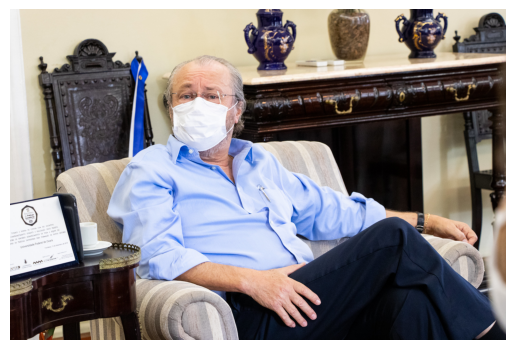

In [5]:
# Example dataset (COCO-style for detection)
from datasets import load_dataset
dataset = load_dataset("cppe-5")  # small object detection dataset

def show_example(example):
    image = example["image"]
    plt.imshow(image)
    plt.axis("off")
    plt.show()

show_example(dataset["train"][4])

### Object Detection

In [6]:
%%writefile -a det_train.py
processor = DetrImageProcessor.from_pretrained("facebook/detr-resnet-50")

def transform(examples):
    # Ensure images are RGB
    images = [img.convert("RGB") for img in examples["image"]]
    
    batch_annotations = []
    for i in range(len(images)):
        objs = examples["objects"][i]
        formatted_objs = []
        
        # Check if objects has bboxes to avoid empty list errors
        if "bbox" in objs:
            for j in range(len(objs["bbox"])):
                formatted_objs.append({
                    "bbox": objs["bbox"][j],
                    "category_id": objs["category"][j],
                    "area": objs.get("area", [0]*len(objs["bbox"]))[j],
                    "iscrowd": 0
                })

        batch_annotations.append({
            "image_id": examples["image_id"][i],
            "annotations": formatted_objs
        })

    # Process - do NOT return tensors as "pt" here if using set_transform
    # Let the processor handle the image scaling/normalization
    encoding = processor(images=images, annotations=batch_annotations, return_tensors="pt")
    
    # Convert tensors to lists so they can be re-batched by DataLoader
    return {k: list(v) for k, v in encoding.items()}




# Apply the transform
dataset["train"].set_transform(transform)

Appending to det_train.py


In [7]:
%%writefile -a det_train.py
from torch.utils.data import DataLoader

def collate_fn(batch):
    pixel_values = [item["pixel_values"] for item in batch]
    encoding = {"pixel_values": torch.stack(pixel_values)}

    # Keep labels as a list of dictionaries
    if "labels" in batch[0]:
        encoding["labels"] = [item["labels"] for item in batch]

    return encoding

# Load in the training data, as a batch of 4, removes order bias with shuffle=True.
train_loader = DataLoader(
    dataset["train"], 
    batch_size=4, 
    shuffle=True, 
    collate_fn=collate_fn
)


Appending to det_train.py


In [8]:
%%writefile -a det_train.py
model = DetrForObjectDetection.from_pretrained(
    "facebook/detr-resnet-50",
    num_labels=91,
    ignore_mismatched_sizes=True
)

model.to(device)

Appending to det_train.py


In [9]:
%%writefile -a det_train.py
# Training Loop (D2L)
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)

num_epochs = 3

for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for batch in train_loader:
        pixel_values = batch["pixel_values"].to(device)
        labels = [{k: v.to(device) for k, v in t.items()} for t in batch["labels"]]

        outputs = model(pixel_values=pixel_values, labels=labels)
        loss = outputs.loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Appending to det_train.py


In [10]:
%%writefile -a det_train.py
# Inference (Detection)
model.eval()

sample = dataset["test"][0]  # cppe-5 has a 'test' split with 29 images

inputs = processor(images=sample["image"], return_tensors="pt").to(device)

with torch.no_grad():
    outputs = model(**inputs)

results = processor.post_process_object_detection(
    outputs,
    target_sizes=[sample["image"].size[::-1]]
)[0]

print(results)

Appending to det_train.py


Write the slurm job script to be used to submit the job

In [8]:
%%writefile submit_det_job.sl
#!/bin/bash
#SBATCH --job-name=ViT_NeSI
#SBATCH --account=nesi99999         # <--- CHANGE THIS to your project code
#SBATCH --time=00:15:00
#SBATCH --mem=16G
#SBATCH --ntasks=1
#SBATCH --cpus-per-task=4
#SBATCH --gpus-per-node=L4:1
#SBATCH --output=vit_output_%j.log

# 1. Load the Miniconda module
module purge
module load Miniconda3

# 2. Activate conda environment using the subshell workaround
# This ensures the shell functions are available for 'conda activate'
source $(conda info --base)/etc/profile.d/conda.sh
conda deactivate  # Workaround for activation issues in some Slurm environments

# 3. Target your specific environment path
conda activate /nesi/project/nesi99999/thomas.li/pytorch_ml

# module load Python/3.10.5-gimkl-2022a
# module load CUDA/11.7.0

# Run the script
srun python det_train.py

Overwriting submit_det_job.sl


In [9]:
!sbatch submit_det_job.sl

Submitted batch job 5764968


In [10]:
# It takes about 5-10 minutes for this script to run in the GPU
!squeue -u $USER

             JOBID PARTITION     NAME     USER ST       TIME  NODES NODELIST(REASON)
           5764919     genoa ViT_NeSI thomas.l  R       1:28      1 g12
           5764968 milan,gen ViT_NeSI thomas.l PD       0:00      1 (Resources)


#### Segmentation (SegFormer)

In [ ]:
# Load Segmentation Dataset
dataset_seg = load_dataset("scene_parse_150", trust_remote_code=True)  # ADE20K subset

dataset_seg

In [8]:
# Preprocessing (SegFormer)
seg_processor = SegformerImageProcessor.from_pretrained("nvidia/segformer-b0-finetuned-ade-512-512")

def seg_transform(example):
    image = example["image"]
    mask = example["annotation"]

    encoding = seg_processor(
        images=image,
        segmentation_maps=mask,
        return_tensors="pt"
    )

    encoding = {k: v.squeeze() for k, v in encoding.items()}
    return encoding

dataset_seg = dataset_seg.with_transform(seg_transform)

preprocessor_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

In [10]:
# DataLoader
from torch.utils.data import DataLoader
def seg_collate_fn(batch):
    pixel_values = torch.stack([x["pixel_values"] for x in batch])
    labels = torch.stack([x["labels"] for x in batch])
    return {"pixel_values": pixel_values, "labels": labels}

train_loader_seg = DataLoader(dataset_seg["train"], batch_size=2, collate_fn=seg_collate_fn)

In [11]:
# Model
seg_model = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/segformer-b0-finetuned-ade-512-512"
)

seg_model.to(device)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/15.0M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

SegformerForSemanticSegmentation(
  (segformer): SegformerModel(
    (encoder): SegformerEncoder(
      (patch_embeddings): ModuleList(
        (0): SegformerOverlapPatchEmbeddings(
          (proj): Conv2d(3, 32, kernel_size=(7, 7), stride=(4, 4), padding=(3, 3))
          (layer_norm): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        )
        (1): SegformerOverlapPatchEmbeddings(
          (proj): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
          (layer_norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        )
        (2): SegformerOverlapPatchEmbeddings(
          (proj): Conv2d(64, 160, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
          (layer_norm): LayerNorm((160,), eps=1e-05, elementwise_affine=True)
        )
        (3): SegformerOverlapPatchEmbeddings(
          (proj): Conv2d(160, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
          (layer_norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  

In [ ]:
# Training Loop
optimizer = torch.optim.AdamW(seg_model.parameters(), lr=5e-5)

for epoch in range(3):
    seg_model.train()
    total_loss = 0

    for batch in train_loader_seg:
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        outputs = seg_model(pixel_values=pixel_values, labels=labels)
        loss = outputs.loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"[Seg] Epoch {epoch+1}, Loss: {total_loss:.4f}")

In [ ]:
# Inference + Visualization
seg_model.eval()

sample = dataset_seg["validation"][0]
inputs = seg_processor(images=sample["image"], return_tensors="pt").to(device)

with torch.no_grad():
    outputs = seg_model(**inputs)

pred_mask = outputs.logits.argmax(dim=1).cpu().numpy()[0]

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(sample["image"])
plt.title("Image")

plt.subplot(1,2,2)
plt.imshow(pred_mask)
plt.title("Predicted Mask")

plt.show()

#### Exercise To Do

Extend this into:

✅ full COCO training pipeline

✅ custom dataset (YOLO → DETR conversion)